In [1]:
import numpy as np
import sys 
import sys
sys.path.append('../scripts')
import assembly_tree as at
sys.path.append('../scripts')
import mcmc 
import networkx as nx 
import matplotlib.pyplot as plt 
import numpy as np 
import json
import os
import treelib
import importlib
import copy
#import pandas as pd

importlib.reload(at)

<module 'assembly_tree' from '/Users/glover.co/Documents/laszlo/NetDesign/scripts/assembly_tree.py'>

In [2]:
# Open json
with open('../data/proteins/human/treefiles/CPX-1919_tree.json','r') as f:
    tree_data = json.load(f)

In [21]:
target = nx.read_edgelist('../data/proteins/human/edgefiles/CPX-1919.edge', nodetype=int,create_using=nx.Graph, data=(('weight', float),))
X = np.loadtxt('../data/proteins/human/Xfiles/X_CPX-1919.txt', delimiter=' ')
capacity = at.extract_deg_cap(target, X).T[0]
O = at.extract_O(target,X)

In [127]:
len(tree_data)

14

In [128]:
new_tree = mcmc.AssemblyTree(target, X, O, capacity)

In [141]:
def create_tree_from_json(f,tree,parent=None):
    nodes_to_add = list(f.keys())
    if 'success' in nodes_to_add:
        nodes_to_add.remove('success')        
    while len(nodes_to_add) > 0:
        node = nodes_to_add.pop(0)
        if parent is not None:
            tree.Tree.create_node(int(node), int(node), parent=parent, data=mcmc.AssemblyNode(f[node]['data'],tree.X,tree.O,tree.capacity))
        # Check whether node has children
        if 'children' in f[str(node)]:
            children = f[str(node)]['children']
            for child in children:
                create_tree_from_json(child, tree, parent=int(node))
        tree.update_prob(int(node))
    return tree

In [142]:
assembly_trees = [create_tree_from_json(tree_data[i],copy.deepcopy(new_tree)) for i in range(len(tree_data))]

In [143]:
assembly_trees

In [145]:
depths = [tree.Tree.depth() for tree in assembly_trees]

(array([5., 0., 0., 0., 0., 0., 0., 0., 0., 9.]),
 array([3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. ]),
 <BarContainer object of 10 artists>)

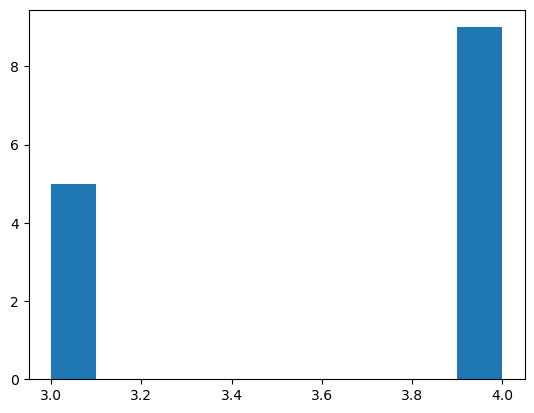

In [146]:
plt.hist(depths)

In [182]:
assembly_trees[13].Tree.show()

0
├── 20
│   ├── 87
│   ├── 119
│   └── 120
├── 36
│   ├── 105
│   └── 116
│       ├── 106
│       │   ├── 128
│       │   └── 129
│       └── 107
└── 118
    ├── 121
    └── 127



Text(0.5, 1.0, '[np.float64(1.0)]')

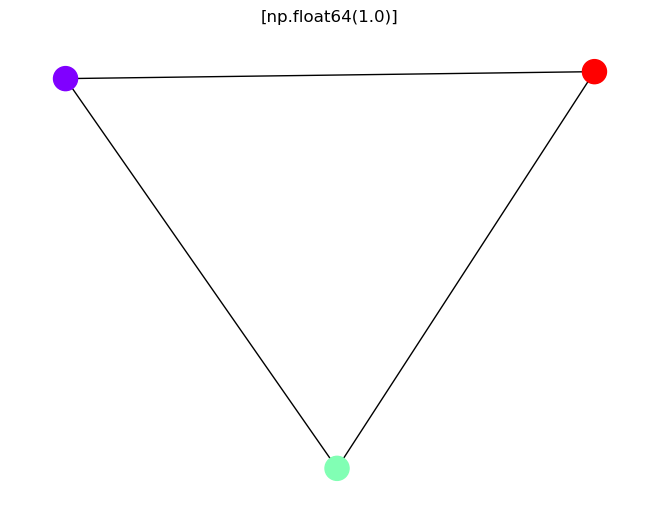

In [176]:
at.draw_network(assembly_trees[9].Tree.get_node(127).data.subgraph[0],X)
plt.title(assembly_trees[9].Tree.get_node(127).data.p)

In [91]:
new_tree.Tree.get_node(87).data.p

[np.float64(1.0)]